<a href="https://colab.research.google.com/github/Ebrar6565/smart-city-satellite-analysis/blob/main/notebooks/02_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Veri Ön İşleme ve PyTorch Dataset Hazırlığı

Bu notebook içerisinde uydu görüntüleri ve karşılık gelen semantic segmentation maskeleri derin öğrenme modeline uygun hâle getirilecektir.

Gerçekleştirilecek işlemler:

- Google Drive üzerindeki örnek verilerin okunması
- Görüntü ve maske dosyalarının eşleştirilmesi
- Görüntü ve maskelerin boyutlarının incelenmesi
- Görüntülerin yeniden boyutlandırılması
- Maske sınıf değerlerinin korunması
- Görüntülerin PyTorch tensörüne dönüştürülmesi
- Dataset ve DataLoader yapılarının oluşturulması

Bu aşamada kullanılan 40 görüntü–maske çifti yalnızca veri işleme hattını test etmek amacıyla kullanılacaktır. Final model eğitimi LoveDA eğitim verisi üzerinde gerçekleştirilecektir.

In [1]:
import os
import random

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

print("Temel kütüphaneler başarıyla yüklendi.")

Temel kütüphaneler başarıyla yüklendi.


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
sample_root = Path(
    "/content/drive/MyDrive/"
    "smart-city-satellite-analysis/data_samples"
)

urban_image_dir = sample_root / "Urban" / "images"
urban_mask_dir = sample_root / "Urban" / "masks"

rural_image_dir = sample_root / "Rural" / "images"
rural_mask_dir = sample_root / "Rural" / "masks"

print("Ana veri klasörü:")
print(sample_root)

print("\nKlasör kontrolleri:")

print(
    "Urban images:",
    urban_image_dir.exists()
)

print(
    "Urban masks:",
    urban_mask_dir.exists()
)

print(
    "Rural images:",
    rural_image_dir.exists()
)

print(
    "Rural masks:",
    rural_mask_dir.exists()
)

Ana veri klasörü:
/content/drive/MyDrive/smart-city-satellite-analysis/data_samples

Klasör kontrolleri:
Urban images: True
Urban masks: True
Rural images: True
Rural masks: True


In [4]:
def find_matching_files(
    image_directory,
    mask_directory
):
    image_files = {
        file_path.name
        for file_path in image_directory.glob("*.png")
    }

    mask_files = {
        file_path.name
        for file_path in mask_directory.glob("*.png")
    }

    matching_files = sorted(
        image_files & mask_files
    )

    return matching_files


urban_files = find_matching_files(
    urban_image_dir,
    urban_mask_dir
)

rural_files = find_matching_files(
    rural_image_dir,
    rural_mask_dir
)

print("Urban eşleşen çift sayısı:", len(urban_files))
print("Rural eşleşen çift sayısı:", len(rural_files))
print("Toplam çift sayısı:", len(urban_files) + len(rural_files))

print("\nİlk 5 Urban dosyası:")
print(urban_files[:5])

print("\nİlk 5 Rural dosyası:")
print(rural_files[:5])

Urban eşleşen çift sayısı: 20
Rural eşleşen çift sayısı: 20
Toplam çift sayısı: 40

İlk 5 Urban dosyası:
['3539.png', '3541.png', '3544.png', '3546.png', '3603.png']

İlk 5 Rural dosyası:
['2528.png', '2685.png', '2725.png', '2747.png', '2806.png']


In [5]:
sample_file_name = urban_files[0]

sample_image_path = (
    urban_image_dir / sample_file_name
)

sample_mask_path = (
    urban_mask_dir / sample_file_name
)

sample_image = Image.open(
    sample_image_path
).convert("RGB")

sample_mask = Image.open(
    sample_mask_path
)

print("Seçilen dosya:", sample_file_name)

print("\nPIL görüntü bilgileri:")
print("Uydu görüntüsü boyutu:", sample_image.size)
print("Uydu görüntüsü modu:", sample_image.mode)

print("\nPIL maske bilgileri:")
print("Maske boyutu:", sample_mask.size)
print("Maske modu:", sample_mask.mode)

Seçilen dosya: 3539.png

PIL görüntü bilgileri:
Uydu görüntüsü boyutu: (1024, 1024)
Uydu görüntüsü modu: RGB

PIL maske bilgileri:
Maske boyutu: (1024, 1024)
Maske modu: L


In [6]:
sample_image_array = np.array(sample_image)
sample_mask_array = np.array(sample_mask)

print("Uydu görüntüsü NumPy boyutu:")
print(sample_image_array.shape)

print("\nMaske NumPy boyutu:")
print(sample_mask_array.shape)

print("\nUydu görüntüsü veri tipi:")
print(sample_image_array.dtype)

print("\nMaske veri tipi:")
print(sample_mask_array.dtype)

print("\nMaskede bulunan sınıflar:")
print(np.unique(sample_mask_array))

Uydu görüntüsü NumPy boyutu:
(1024, 1024, 3)

Maske NumPy boyutu:
(1024, 1024)

Uydu görüntüsü veri tipi:
uint8

Maske veri tipi:
uint8

Maskede bulunan sınıflar:
[1 2 3 4 5 6 7]


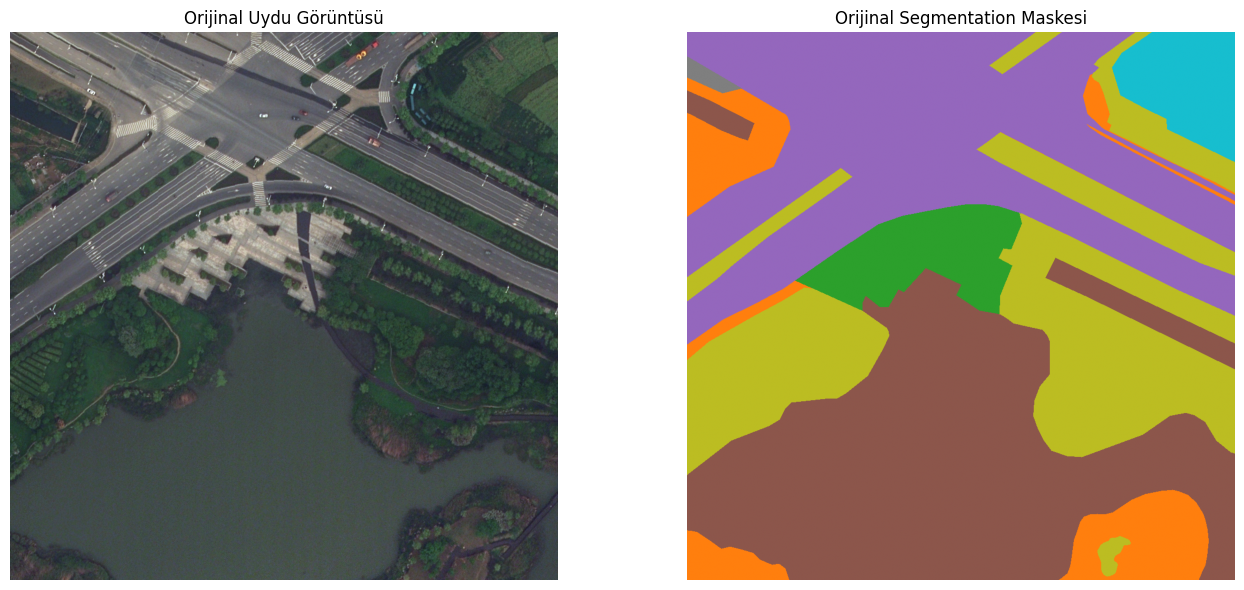

In [7]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(sample_image_array)
plt.title("Orijinal Uydu Görüntüsü")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    sample_mask_array,
    cmap=plt.get_cmap("tab10", 8),
    vmin=0,
    vmax=7
)
plt.title("Orijinal Segmentation Maskesi")
plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# Modelde kullanmak istediğimiz hedef boyut
target_size = (256, 256)

# Uydu görüntüsünü yeniden boyutlandırıyoruz
resized_image = sample_image.resize(
    target_size,
    resample=Image.Resampling.BILINEAR
)

# Maskeyi yeniden boyutlandırıyoruz
resized_mask = sample_mask.resize(
    target_size,
    resample=Image.Resampling.NEAREST
)

# NumPy dizilerine dönüştürüyoruz
resized_image_array = np.array(resized_image)
resized_mask_array = np.array(resized_mask)

print("Orijinal görüntü boyutu:", sample_image_array.shape)
print("Yeni görüntü boyutu:", resized_image_array.shape)

print("\nOrijinal maske boyutu:", sample_mask_array.shape)
print("Yeni maske boyutu:", resized_mask_array.shape)

print("\nOrijinal maskedeki sınıflar:")
print(np.unique(sample_mask_array))

print("\nKüçültülmüş maskedeki sınıflar:")
print(np.unique(resized_mask_array))

Orijinal görüntü boyutu: (1024, 1024, 3)
Yeni görüntü boyutu: (256, 256, 3)

Orijinal maske boyutu: (1024, 1024)
Yeni maske boyutu: (256, 256)

Orijinal maskedeki sınıflar:
[1 2 3 4 5 6 7]

Küçültülmüş maskedeki sınıflar:
[1 2 3 4 5 6 7]


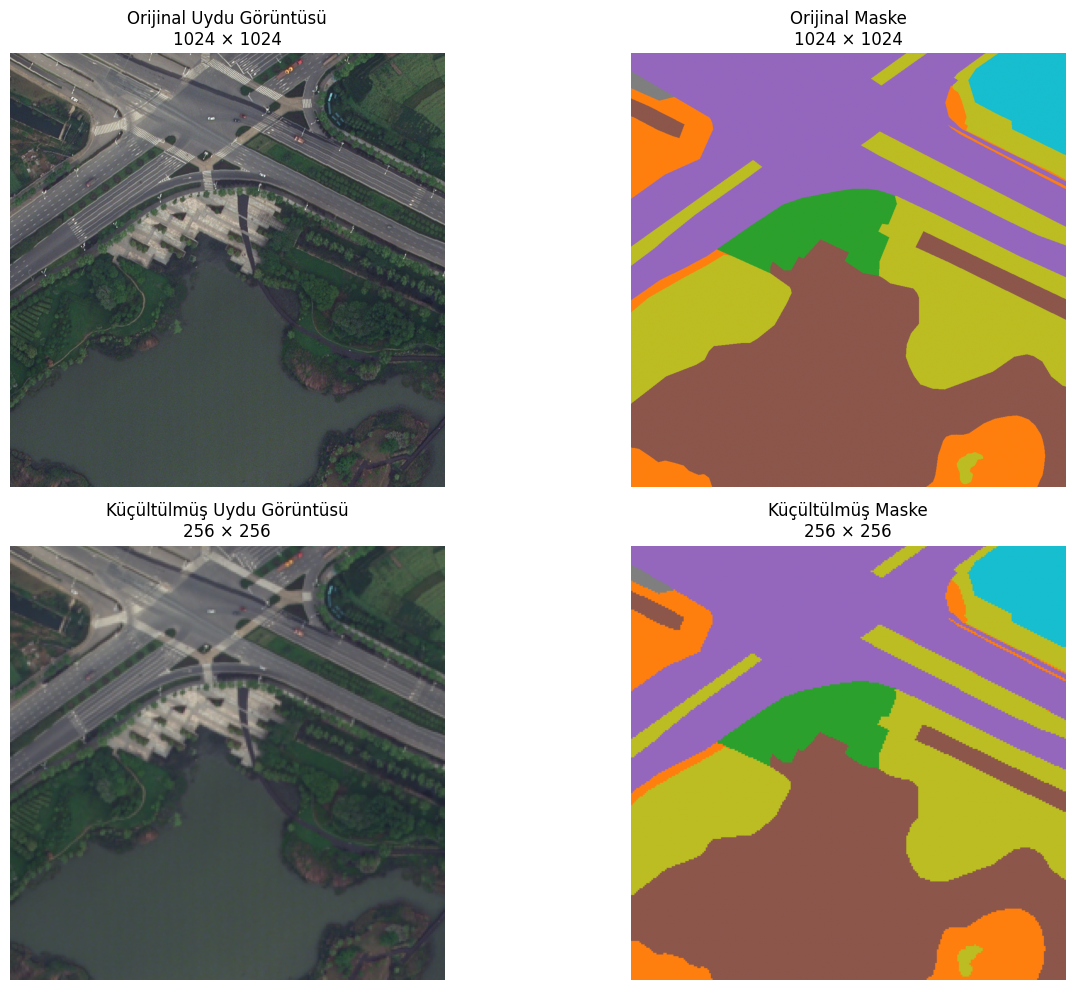

In [10]:
plt.figure(figsize=(14, 10))

# Orijinal uydu görüntüsü
plt.subplot(2, 2, 1)
plt.imshow(sample_image_array)
plt.title("Orijinal Uydu Görüntüsü\n1024 × 1024")
plt.axis("off")

# Orijinal maske
plt.subplot(2, 2, 2)
plt.imshow(
    sample_mask_array,
    cmap=plt.get_cmap("tab10", 8),
    vmin=0,
    vmax=7
)
plt.title("Orijinal Maske\n1024 × 1024")
plt.axis("off")

# Küçültülmüş uydu görüntüsü
plt.subplot(2, 2, 3)
plt.imshow(resized_image_array)
plt.title("Küçültülmüş Uydu Görüntüsü\n256 × 256")
plt.axis("off")

# Küçültülmüş maske
plt.subplot(2, 2, 4)
plt.imshow(
    resized_mask_array,
    cmap=plt.get_cmap("tab10", 8),
    vmin=0,
    vmax=7
)
plt.title("Küçültülmüş Maske\n256 × 256")
plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
print(np.unique(sample_mask_array))
print(np.unique(resized_mask_array))

[1 2 3 4 5 6 7]
[1 2 3 4 5 6 7]


In [12]:
import torch

# NumPy görüntüsü:
# [yükseklik, genişlik, kanal]
# (256, 256, 3)

image_tensor = torch.from_numpy(
    resized_image_array
).permute(2, 0, 1).float()

# Piksel değerlerini 0–255 aralığından 0–1 aralığına getiriyoruz
image_tensor = image_tensor / 255.0

# Maske için sınıf numaralarını koruyoruz
mask_tensor = torch.from_numpy(
    resized_mask_array
).long()

print("Görüntü tensörünün boyutu:", image_tensor.shape)
print("Maske tensörünün boyutu:", mask_tensor.shape)

print("\nGörüntü veri tipi:", image_tensor.dtype)
print("Maske veri tipi:", mask_tensor.dtype)

print("\nGörüntü minimum değeri:", image_tensor.min().item())
print("Görüntü maksimum değeri:", image_tensor.max().item())

print("\nMaskede bulunan sınıflar:")
print(torch.unique(mask_tensor))

Görüntü tensörünün boyutu: torch.Size([3, 256, 256])
Maske tensörünün boyutu: torch.Size([256, 256])

Görüntü veri tipi: torch.float32
Maske veri tipi: torch.int64

Görüntü minimum değeri: 0.09803921729326248
Görüntü maksimum değeri: 0.843137264251709

Maskede bulunan sınıflar:
tensor([1, 2, 3, 4, 5, 6, 7])


In [13]:
# Modelde kullanılacak sınıf isimleri
model_class_names = {
    0: "Background",
    1: "Building",
    2: "Road",
    3: "Water",
    4: "Barren",
    5: "Forest",
    6: "Agriculture"
}

IGNORE_INDEX = 255


def remap_loveda_mask(mask_array):
    """
    LoveDA sınıflarını modelin kullanacağı sınıf aralığına dönüştürür.

    LoveDA:
        0     -> 255 (ignore)
        1-7   -> 0-6
    """

    remapped_mask = np.full(
        mask_array.shape,
        IGNORE_INDEX,
        dtype=np.uint8
    )

    valid_pixels = mask_array > 0

    remapped_mask[valid_pixels] = (
        mask_array[valid_pixels] - 1
    )

    return remapped_mask


remapped_mask_array = remap_loveda_mask(
    resized_mask_array
)

print("Dönüştürmeden önceki sınıflar:")
print(np.unique(resized_mask_array))

print("\nDönüştürmeden sonraki sınıflar:")
print(np.unique(remapped_mask_array))

Dönüştürmeden önceki sınıflar:
[1 2 3 4 5 6 7]

Dönüştürmeden sonraki sınıflar:
[0 1 2 3 4 5 6]


## PyTorch Dataset Sınıfının Oluşturulması

Dataset sınıfı, istenen indeks için ilgili uydu görüntüsünü ve aynı dosya adına sahip maskeyi okuyarak modele uygun tensörler döndürecektir.

Her örnek için gerçekleştirilecek işlemler:

1. Uydu görüntüsünü açma
2. Aynı isimli maskeyi açma
3. İkisini 256 × 256 boyutuna getirme
4. Maske sınıflarını 0–6 aralığına dönüştürme
5. Görüntüyü float tensöre çevirme
6. Maskeyi long tensöre çevirme

In [14]:
import torch

from torch.utils.data import Dataset


class LoveDASampleDataset(Dataset):

    def __init__(
        self,
        image_directory,
        mask_directory,
        file_names,
        target_size=(256, 256)
    ):
        self.image_directory = Path(image_directory)
        self.mask_directory = Path(mask_directory)
        self.file_names = list(file_names)
        self.target_size = target_size

    def __len__(self):
        """
        Veri setinde kaç görüntü-mask çifti olduğunu döndürür.
        """
        return len(self.file_names)

    def __getitem__(self, index):
        """
        Verilen indeks için bir görüntü ve maskeyi hazırlar.
        """

        file_name = self.file_names[index]

        image_path = (
            self.image_directory / file_name
        )

        mask_path = (
            self.mask_directory / file_name
        )

        # Dosyaları aç
        image = Image.open(
            image_path
        ).convert("RGB")

        mask = Image.open(mask_path)

        # Aynı hedef boyuta getir
        image = image.resize(
            self.target_size,
            resample=Image.Resampling.BILINEAR
        )

        mask = mask.resize(
            self.target_size,
            resample=Image.Resampling.NEAREST
        )

        # NumPy dizisine çevir
        image_array = np.array(
            image,
            dtype=np.float32
        )

        mask_array = np.array(
            mask,
            dtype=np.uint8
        )

        # LoveDA sınıflarını 0-6 aralığına getir
        mask_array = remap_loveda_mask(
            mask_array
        )

        # Görüntü:
        # [H, W, C] → [C, H, W]
        image_tensor = torch.from_numpy(
            image_array
        ).permute(2, 0, 1)

        # 0-255 → 0-1
        image_tensor = image_tensor / 255.0

        # Maske sınıf numaralarıdır
        mask_tensor = torch.from_numpy(
            mask_array.astype(np.int64)
        )

        return image_tensor, mask_tensor

In [15]:
all_sample_records = []

for file_name in urban_files:
    all_sample_records.append(
        {
            "region": "Urban",
            "file_name": file_name
        }
    )

for file_name in rural_files:
    all_sample_records.append(
        {
            "region": "Rural",
            "file_name": file_name
        }
    )

print("Toplam kayıt sayısı:", len(all_sample_records))

Toplam kayıt sayısı: 40


In [16]:
urban_dataset = LoveDASampleDataset(
    image_directory=urban_image_dir,
    mask_directory=urban_mask_dir,
    file_names=urban_files,
    target_size=(256, 256)
)

rural_dataset = LoveDASampleDataset(
    image_directory=rural_image_dir,
    mask_directory=rural_mask_dir,
    file_names=rural_files,
    target_size=(256, 256)
)

print("Urban Dataset uzunluğu:", len(urban_dataset))
print("Rural Dataset uzunluğu:", len(rural_dataset))

Urban Dataset uzunluğu: 20
Rural Dataset uzunluğu: 20


In [17]:
dataset_image, dataset_mask = urban_dataset[0]

print("Dataset görüntü boyutu:", dataset_image.shape)
print("Dataset maske boyutu:", dataset_mask.shape)

print("\nGörüntü veri tipi:", dataset_image.dtype)
print("Maske veri tipi:", dataset_mask.dtype)

print("\nGörüntü değer aralığı:")
print(
    dataset_image.min().item(),
    dataset_image.max().item()
)

print("\nYeni maske sınıfları:")
print(torch.unique(dataset_mask))

Dataset görüntü boyutu: torch.Size([3, 256, 256])
Dataset maske boyutu: torch.Size([256, 256])

Görüntü veri tipi: torch.float32
Maske veri tipi: torch.int64

Görüntü değer aralığı:
0.09803921729326248 0.843137264251709

Yeni maske sınıfları:
tensor([0, 1, 2, 3, 4, 5, 6])


In [18]:
urban_dataset[0]
urban_dataset[1]
urban_dataset[2]

(tensor([[[0.1725, 0.1608, 0.1490,  ..., 0.3922, 0.3294, 0.3176],
          [0.1686, 0.1608, 0.1529,  ..., 0.4196, 0.3137, 0.2902],
          [0.1569, 0.1529, 0.1569,  ..., 0.4039, 0.2824, 0.2784],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
         [[0.1882, 0.1765, 0.1765,  ..., 0.3451, 0.2941, 0.2863],
          [0.1843, 0.1804, 0.1882,  ..., 0.3804, 0.2745, 0.2667],
          [0.1804, 0.1843, 0.1882,  ..., 0.3765, 0.2588, 0.2667],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
         [[0.1843, 0.1961, 0.1843,  ..., 0.3176, 0.2824, 0.2784],
          [0.1922, 0.1922, 0.1882,  ..., 0.3451, 0.2510, 0.2471],
          [0.1922, 0.1961, 0.1961,  ...,

In [19]:
dataset_image, dataset_mask = urban_dataset[0]

print("Görüntü boyutu:", dataset_image.shape)
print("Maske boyutu:", dataset_mask.shape)

print("\nGörüntü veri tipi:", dataset_image.dtype)
print("Maske veri tipi:", dataset_mask.dtype)

print("\nGörüntü değer aralığı:")
print(
    dataset_image.min().item(),
    dataset_image.max().item()
)

print("\nMaskede bulunan değerler:")
print(torch.unique(dataset_mask))

ignore_pixel_count = torch.sum(
    dataset_mask == 255
).item()

valid_pixel_count = torch.sum(
    dataset_mask != 255
).item()

print("\nGeçerli piksel sayısı:", valid_pixel_count)
print("Yok sayılacak piksel sayısı:", ignore_pixel_count)

Görüntü boyutu: torch.Size([3, 256, 256])
Maske boyutu: torch.Size([256, 256])

Görüntü veri tipi: torch.float32
Maske veri tipi: torch.int64

Görüntü değer aralığı:
0.09803921729326248 0.843137264251709

Maskede bulunan değerler:
tensor([0, 1, 2, 3, 4, 5, 6])

Geçerli piksel sayısı: 65536
Yok sayılacak piksel sayısı: 0


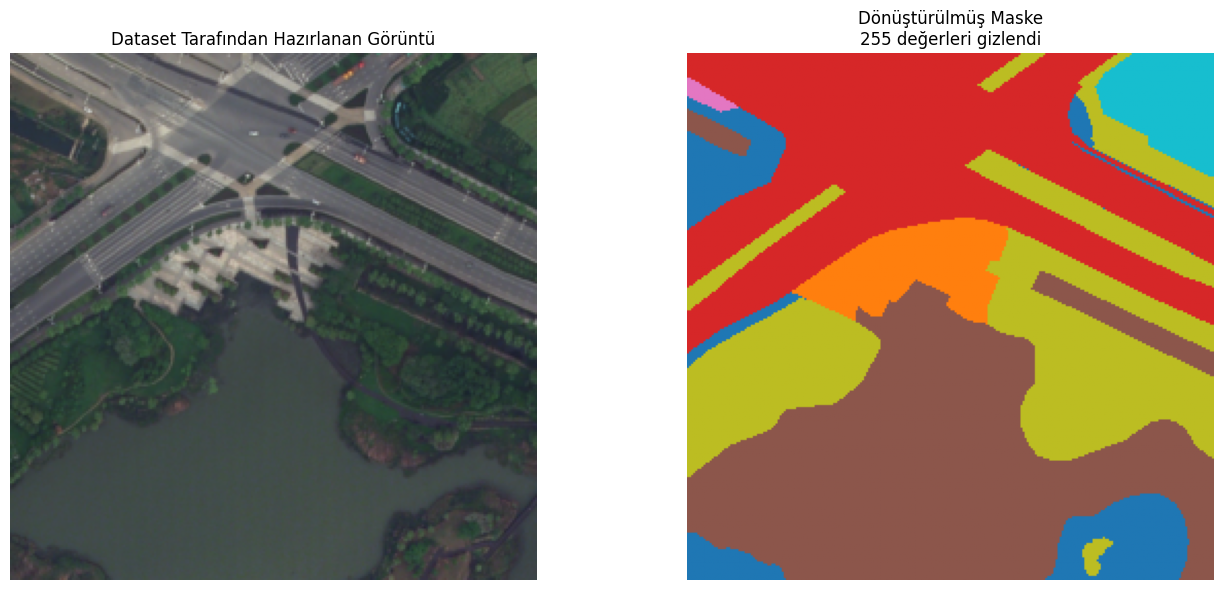

In [20]:
image_for_display = (
    dataset_image
    .permute(1, 2, 0)
    .numpy()
)

mask_for_display = dataset_mask.numpy()

visible_mask = np.ma.masked_where(
    mask_for_display == 255,
    mask_for_display
)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(image_for_display)
plt.title("Dataset Tarafından Hazırlanan Görüntü")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    visible_mask,
    cmap=plt.get_cmap("tab10", 7),
    vmin=0,
    vmax=6
)
plt.title("Dönüştürülmüş Maske\n255 değerleri gizlendi")
plt.axis("off")

plt.tight_layout()
plt.show()

## Datasetlerin Birleştirilmesi ve DataLoader Oluşturulması

Urban ve Rural veri setleri birleştirilerek tek bir veri seti hâline getirilecektir.

DataLoader, görüntü ve maskeleri belirlenen batch boyutunda hazırlayarak model eğitimine aktaracaktır.

In [21]:
from torch.utils.data import ConcatDataset, DataLoader

# Urban ve Rural Datasetlerini tek bir Dataset hâline getiriyoruz
combined_dataset = ConcatDataset([
    urban_dataset,
    rural_dataset
])

print("Urban örnek sayısı:", len(urban_dataset))
print("Rural örnek sayısı:", len(rural_dataset))
print("Birleştirilmiş örnek sayısı:", len(combined_dataset))

Urban örnek sayısı: 20
Rural örnek sayısı: 20
Birleştirilmiş örnek sayısı: 40


In [22]:
BATCH_SIZE = 4

sample_dataloader = DataLoader(
    combined_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

print("Toplam örnek sayısı:", len(combined_dataset))
print("Batch boyutu:", BATCH_SIZE)
print("Toplam batch sayısı:", len(sample_dataloader))

Toplam örnek sayısı: 40
Batch boyutu: 4
Toplam batch sayısı: 10


In [23]:
batch_images, batch_masks = next(
    iter(sample_dataloader)
)

print("Batch görüntülerinin boyutu:")
print(batch_images.shape)

print("\nBatch maskelerinin boyutu:")
print(batch_masks.shape)

print("\nGörüntü veri tipi:")
print(batch_images.dtype)

print("\nMaske veri tipi:")
print(batch_masks.dtype)

print("\nBatch maskelerinde bulunan değerler:")
print(torch.unique(batch_masks))

Batch görüntülerinin boyutu:
torch.Size([4, 3, 256, 256])

Batch maskelerinin boyutu:
torch.Size([4, 256, 256])

Görüntü veri tipi:
torch.float32

Maske veri tipi:
torch.int64

Batch maskelerinde bulunan değerler:
tensor([0, 1, 2, 3, 4, 5, 6])


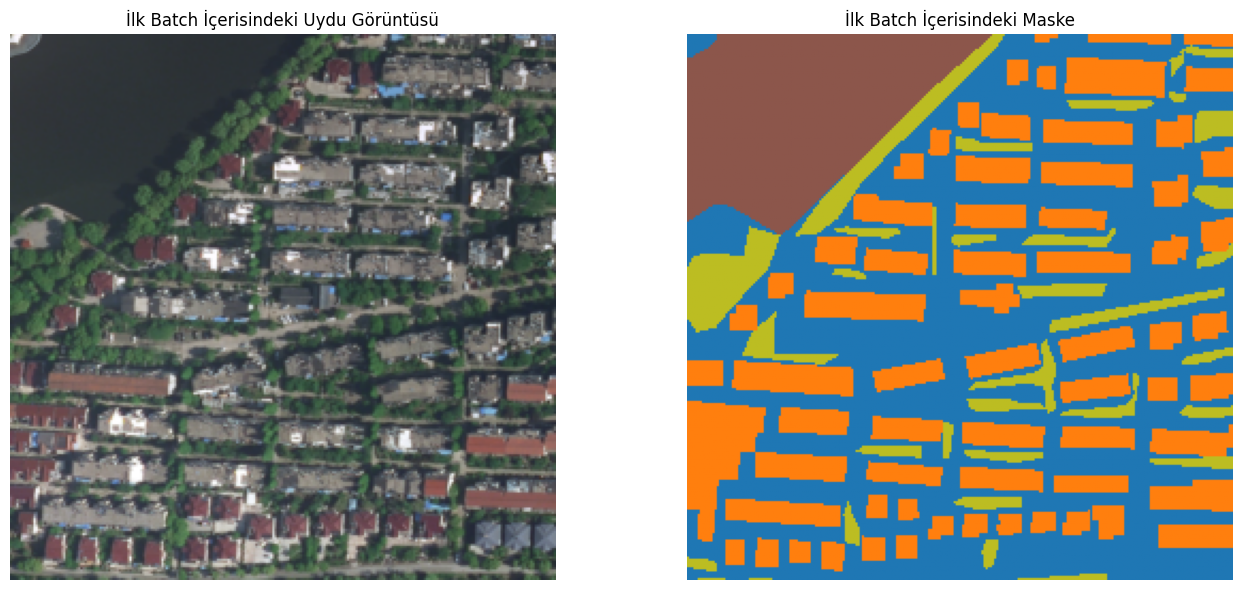

In [24]:
first_batch_image = (
    batch_images[0]
    .permute(1, 2, 0)
    .numpy()
)

first_batch_mask = (
    batch_masks[0]
    .numpy()
)

visible_batch_mask = np.ma.masked_where(
    first_batch_mask == 255,
    first_batch_mask
)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(first_batch_image)
plt.title("İlk Batch İçerisindeki Uydu Görüntüsü")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    visible_batch_mask,
    cmap=plt.get_cmap("tab10", 7),
    vmin=0,
    vmax=6
)
plt.title("İlk Batch İçerisindeki Maske")
plt.axis("off")

plt.tight_layout()
plt.show()